# Does Cleaner Data Beat More Data? - results & plots
Runs all 3 experiments & all plots are saved to `results/`

In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RESULTS_DIR = Path('../results')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
COLORS = {'logreg': '#4C72B0', 'distilbert': '#DD8452'}

def load(filename):
    with open(RESULTS_DIR / f'{filename}.json') as f:
        return json.load(f)

def save_fig(name):
    path = RESULTS_DIR / f'{name}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'saved → {path}')
    plt.show()

## Plot 1 - Degradation Curves
Experiment 1: F1 vs noise level for both models

saved → ../results/plot_degradation_curves.png


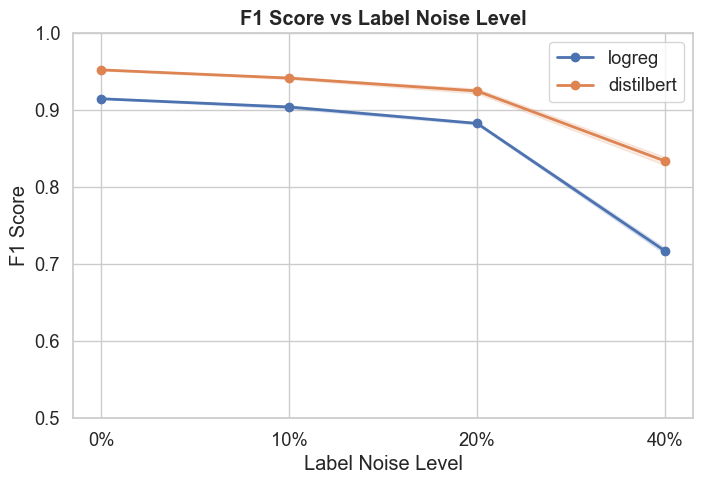

In [13]:
logreg_sweep = load('noise_sweep_logreg')
distilbert_sweep = load('noise_sweep_distilbert')

noise_levels = [float(k) for k in logreg_sweep.keys()]
noise_labels = [f'{int(n*100)}%' for n in noise_levels]

fig, ax = plt.subplots(figsize=(8, 5))

for name, data in [('logreg', logreg_sweep), ('distilbert', distilbert_sweep)]:
    means = [data[str(n)]['f1_mean'] for n in noise_levels]
    stds  = [data[str(n)]['f1_std']  for n in noise_levels]
    ax.plot(noise_labels, means, marker='o', label=name, color=COLORS[name], linewidth=2)
    ax.fill_between(
        noise_labels,
        [m - s for m, s in zip(means, stds)],
        [m + s for m, s in zip(means, stds)],
        alpha=0.15, color=COLORS[name]
    )

ax.set_title('F1 Score vs Label Noise Level', fontweight='bold')
ax.set_xlabel('Label Noise Level')
ax.set_ylabel('F1 Score')
ax.legend()
ax.set_ylim(0.5, 1.0)

save_fig('plot_degradation_curves')

## Plot 2 - Cleaning Recovery
Grouped bars showing F1 before and after each cleaning strategy.

saved → ../results/plot_cleaning_recovery_logreg.png


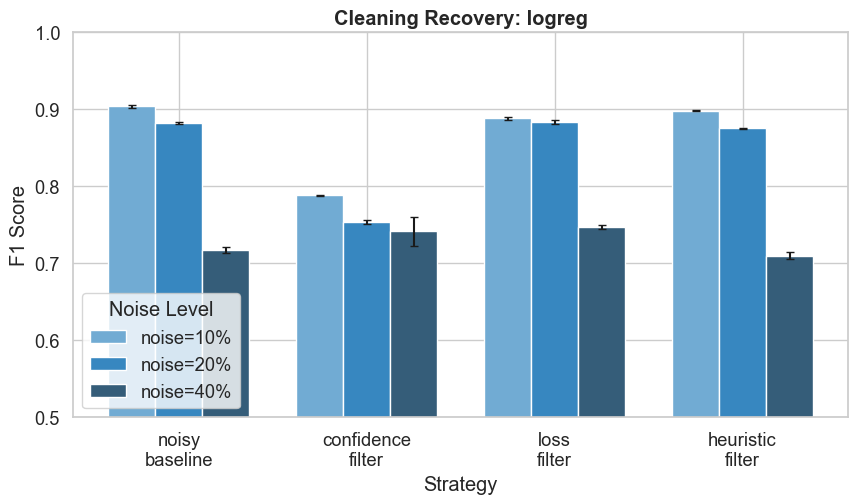

saved → ../results/plot_cleaning_recovery_distilbert.png


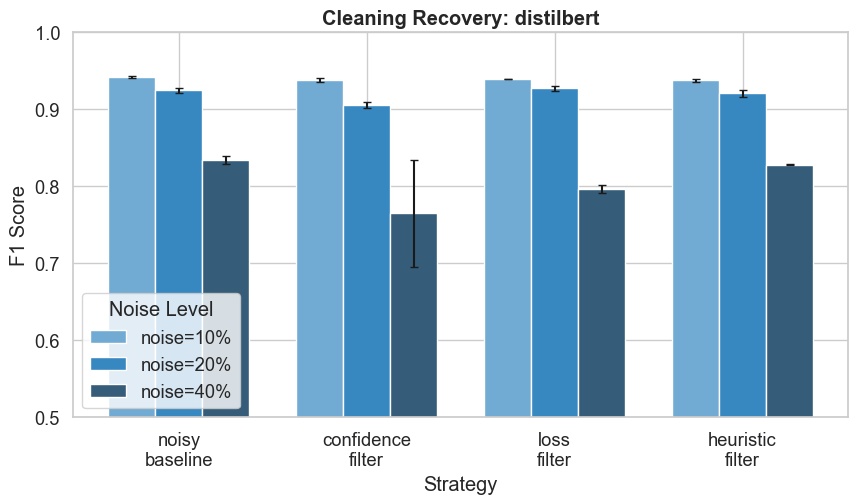

In [14]:
for model_name in ['logreg', 'distilbert']:
    cleaning_data = load(f'cleaning_{model_name}')
    noise_levels_str = list(cleaning_data.keys())
    strategies = ['noisy_baseline', 'confidence', 'loss', 'heuristic']
    strategy_labels = ['noisy\nbaseline', 'confidence\nfilter', 'loss\nfilter', 'heuristic\nfilter']

    x = np.arange(len(strategies))
    width = 0.25
    n_levels = len(noise_levels_str)
    offsets = np.linspace(-(n_levels-1)/2 * width, (n_levels-1)/2 * width, n_levels)
    palette = sns.color_palette('Blues_d', n_colors=n_levels)

    fig, ax = plt.subplots(figsize=(10, 5))

    for idx, noise_level_str in enumerate(noise_levels_str):
        f1_means = [cleaning_data[noise_level_str][s]['f1_mean'] for s in strategies]
        f1_stds  = [cleaning_data[noise_level_str][s]['f1_std']  for s in strategies]
        bars = ax.bar(
            x + offsets[idx], f1_means, width,
            label=f'noise={float(noise_level_str):.0%}',
            color=palette[idx], yerr=f1_stds, capsize=3
        )

    ax.set_title(f'Cleaning Recovery: {model_name}', fontweight='bold')
    ax.set_xlabel('Strategy')
    ax.set_ylabel('F1 Score')
    ax.set_xticks(x)
    ax.set_xticklabels(strategy_labels)
    ax.legend(title='Noise Level')
    ax.set_ylim(0.5, 1.0)

    save_fig(f'plot_cleaning_recovery_{model_name}')

## Plot 3 - Quantity vs Quality
Side by side bars - 50k noisy vs 20k clean.

saved → ../results/plot_quantity_vs_quality_logreg.png


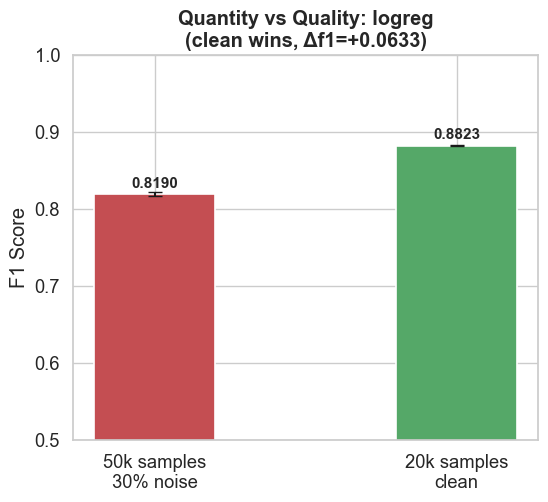

saved → ../results/plot_quantity_vs_quality_distilbert.png


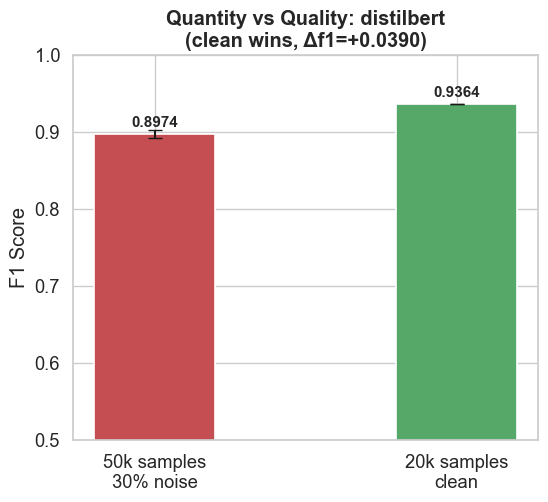

In [15]:
for model_name in ['logreg', 'distilbert']:
    qvq = load(f'quantity_vs_quality_{model_name}')

    scenarios = ['noisy_50k_30pct', 'clean_20k']
    labels    = ['50k samples\n30% noise', '20k samples\nclean']
    f1_means  = [qvq[s]['f1_mean'] for s in scenarios]
    f1_stds   = [qvq[s]['f1_std']  for s in scenarios]
    bar_colors = ['#C44E52', '#55A868']

    fig, ax = plt.subplots(figsize=(6, 5))
    bars = ax.bar(labels, f1_means, color=bar_colors, yerr=f1_stds,
                  capsize=5, width=0.4, edgecolor='white', linewidth=1.2)

    for bar, mean in zip(bars, f1_means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            mean + 0.005,
            f'{mean:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold'
        )

    delta = qvq['delta']['f1']
    winner = 'clean wins' if qvq['delta']['clean_wins'] else 'noisy wins'
    ax.set_title(f'Quantity vs Quality: {model_name}\n({winner}, Δf1={delta:+.4f})', fontweight='bold')
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0.5, 1.0)

    save_fig(f'plot_quantity_vs_quality_{model_name}')

## Summary Table

In [16]:
import pandas as pd

rows = []
for model_name in ['logreg', 'distilbert']:
    sweep = load(f'noise_sweep_{model_name}')
    for noise_level_str, metrics in sweep.items():
        rows.append({
            'model': model_name,
            'noise_level': f'{float(noise_level_str):.0%}',
            'f1_mean': metrics['f1_mean'],
            'f1_std': metrics['f1_std'],
            'acc_mean': metrics['accuracy_mean'],
            'acc_std': metrics['accuracy_std'],
        })

df = pd.DataFrame(rows)
df['F1 (mean ± std)'] = df.apply(lambda r: f"{r['f1_mean']:.4f} ± {r['f1_std']:.4f}", axis=1)
df['Acc (mean ± std)'] = df.apply(lambda r: f"{r['acc_mean']:.4f} ± {r['acc_std']:.4f}", axis=1)
print(df[['model', 'noise_level', 'F1 (mean ± std)', 'Acc (mean ± std)']].to_markdown(index=False))

| model      | noise_level   | F1 (mean ± std)   | Acc (mean ± std)   |
|:-----------|:--------------|:------------------|:-------------------|
| logreg     | 0%            | 0.9149 ± 0.0000   | 0.9038 ± 0.0000    |
| logreg     | 10%           | 0.9042 ± 0.0020   | 0.8914 ± 0.0025    |
| logreg     | 20%           | 0.8829 ± 0.0014   | 0.8674 ± 0.0010    |
| logreg     | 40%           | 0.7172 ± 0.0039   | 0.6865 ± 0.0047    |
| distilbert | 0%            | 0.9524 ± 0.0007   | 0.9469 ± 0.0009    |
| distilbert | 10%           | 0.9418 ± 0.0014   | 0.9352 ± 0.0016    |
| distilbert | 20%           | 0.9250 ± 0.0032   | 0.9165 ± 0.0036    |
| distilbert | 40%           | 0.8340 ± 0.0053   | 0.8144 ± 0.0057    |
